# Step 1 — Import + Load Data
# Step 2 — EDA
# Step 3 — Data Cleaning & Feature Engineering
 # Step 4 — Train ML Model (RandomForest + XGBoost)
# Step 5 — Model Evaluation (R², RMSE)
# Step 6 — SHAP Explainability
# Step 7 — Optimization Engine
# Step 8 — Final Recommendations

In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap


  Using cached scikit_learn-1.7.2-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.16.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached scikit_learn-1.7.2-cp313-cp313-macosx_12_0_arm64.whl (8.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.7 MB/s  0:00:04 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 1.3 MB/s  0:00:0036m-:--:--
Using cached cycler-0.12.1-py3-none-any.whl (8.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb



XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/opt/anaconda3/envs/akasha_de/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <636BF463-1886-392D-B8B3-6011C44DCEE9> /opt/anaconda3/envs/akasha_de/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/anaconda3/envs/akasha_de/lib/python3.13/lib-dynload/../../libomp.dylib' (no such file), '/opt/anaconda3/envs/akasha_de/bin/../lib/libomp.dylib' (no such file)"]


In [4]:
df = pd.read_csv("Synthetic_Farming_Dataset_With_Seasonality_And_Challenge.csv")
df.head()


,soil_pH,soil_N,soil_P,rainfall_mm,temp_avg,fertilizer_kg_per_ha,irrigation_mm,pesticide_ml,input_cost_total,environmental_score,yield_kg_per_ha,date,month,day_of_year,crop_type
0,4.60,118.566628,32.145062,546.135959,22.486917,185.381512,335.363663,90.984308,187.058781,220.936437,4131.007011,2024-04-21,4,112,Wheat
1,6.89,151.800480,18.725041,487.411870,15.077998,68.000877,306.558120,230.030507,164.321215,155.771013,3724.148893,2024-01-07,1,7,Maize
2,6.78,31.557609,22.432062,324.301561,27.094571,83.432856,418.145657,216.111964,190.179148,197.114607,2923.937250,2024-05-07,5,128,Barley
3,8.20,133.871941,6.825415,266.864813,33.643834,26.739131,58.165864,234.025207,95.210300,56.895758,3114.859689,2023-05-24,5,144,Maize
4,7.97,160.373178,31.821689,556.410564,15.028646,59.571880,32.813044,192.473904,94.090720,64.834431,3652.127420,2023-12-25,12,359,Maize


In [5]:
df.sample(6)

,soil_pH,soil_N,soil_P,rainfall_mm,temp_avg,fertilizer_kg_per_ha,irrigation_mm,pesticide_ml,input_cost_total,environmental_score,yield_kg_per_ha,date,month,day_of_year,crop_type
126,6.35,168.956821,25.112441,683.051842,26.374362,178.194777,85.542983,181.126543,160.543948,150.692416,4407.622936,2023-03-07,3,66,Wheat
708,8.18,NaN,13.948486,479.779214,30.235609,56.295460,397.772196,129.452436,146.537900,166.054179,2992.761946,2024-04-11,4,102,Wheat
503,8.09,194.398014,52.550999,663.423603,17.690828,12.758911,421.096865,229.847130,159.552968,156.969119,3621.659820,2024-11-29,11,334,Maize
98,5.84,53.498255,29.071373,632.654478,31.545676,129.030017,97.064385,60.101946,101.958469,112.547520,4088.428991,2025-09-05,9,248,Rice
550,5.88,38.739737,33.609344,455.520127,18.243795,194.513647,427.199757,268.428596,263.225354,271.710975,3536.261709,2024-09-09,9,253,Wheat
985,4.94,25.469671,36.925718,859.184391,29.328464,140.806291,453.326648,261.400078,239.488498,246.621777,3834.901791,2023-07-18,7,199,Rice


In [7]:
print(df.shape)
df.info()
df.isnull().sum()


(1000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   soil_pH               1000 non-null   float64
 1   soil_N                950 non-null    float64
 2   soil_P                1000 non-null   float64
 3   rainfall_mm           950 non-null    float64
 4   temp_avg              1000 non-null   float64
 5   fertilizer_kg_per_ha  950 non-null    float64
 6   irrigation_mm         1000 non-null   float64
 7   pesticide_ml          1000 non-null   float64
 8   input_cost_total      1000 non-null   float64
 9   environmental_score   1000 non-null   float64
 10  yield_kg_per_ha       1000 non-null   float64
 11  date                  1000 non-null   object 
 12  month                 1000 non-null   int64  
 13  day_of_year           1000 non-null   int64  
 14  crop_type             1000 non-null   object 
dtypes: float64(

soil_pH                  0
soil_N                  50
soil_P                   0
rainfall_mm             50
temp_avg                 0
fertilizer_kg_per_ha    50
irrigation_mm            0
pesticide_ml             0
input_cost_total         0
environmental_score      0
yield_kg_per_ha          0
date                     0
month                    0
day_of_year              0
crop_type                0
dtype: int64

In [8]:
df_clean = df.copy()

# Median imputation
impute_cols = ['soil_N', 'rainfall_mm', 'fertilizer_kg_per_ha']
for col in impute_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Convert date
df_clean["date"] = pd.to_datetime(df_clean["date"])

# Create season feature
df_clean["season"] = df_clean["month"].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

# Encode crop type
le = LabelEncoder()
df_clean["crop_type_enc"] = le.fit_transform(df_clean["crop_type"])

df_clean.head()


,soil_pH,soil_N,soil_P,rainfall_mm,temp_avg,fertilizer_kg_per_ha,irrigation_mm,pesticide_ml,input_cost_total,environmental_score,yield_kg_per_ha,date,month,day_of_year,crop_type,season,crop_type_enc
0,4.60,118.566628,32.145062,546.135959,22.486917,185.381512,335.363663,90.984308,187.058781,220.936437,4131.007011,2024-04-21,4,112,Wheat,Spring,3
1,6.89,151.800480,18.725041,487.411870,15.077998,68.000877,306.558120,230.030507,164.321215,155.771013,3724.148893,2024-01-07,1,7,Maize,Winter,1
2,6.78,31.557609,22.432062,324.301561,27.094571,83.432856,418.145657,216.111964,190.179148,197.114607,2923.937250,2024-05-07,5,128,Barley,Spring,0
3,8.20,133.871941,6.825415,266.864813,33.643834,26.739131,58.165864,234.025207,95.210300,56.895758,3114.859689,2023-05-24,5,144,Maize,Spring,1
4,7.97,160.373178,31.821689,556.410564,15.028646,59.571880,32.813044,192.473904,94.090720,64.834431,3652.127420,2023-12-25,12,359,Maize,Winter,1


In [16]:
# ============================================
# STEP 2 — Basic Info
# ============================================

print(df.shape)
df.info()
df.describe().T


(1000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   soil_pH               1000 non-null   float64
 1   soil_N                950 non-null    float64
 2   soil_P                1000 non-null   float64
 3   rainfall_mm           950 non-null    float64
 4   temp_avg              1000 non-null   float64
 5   fertilizer_kg_per_ha  950 non-null    float64
 6   irrigation_mm         1000 non-null   float64
 7   pesticide_ml          1000 non-null   float64
 8   input_cost_total      1000 non-null   float64
 9   environmental_score   1000 non-null   float64
 10  yield_kg_per_ha       1000 non-null   float64
 11  date                  1000 non-null   object 
 12  month                 1000 non-null   int64  
 13  day_of_year           1000 non-null   int64  
 14  crop_type             1000 non-null   object 
dtypes: float64(

,count,mean,std,min,25%,50%,75%,max
soil_pH,1000.0,6.460970,1.168474,4.520000,5.445000,6.490000,7.480000,8.500000
soil_N,950.0,111.477705,52.510328,20.579287,63.385542,113.432742,156.982823,199.894471
soil_P,1000.0,32.632315,15.987081,5.000640,19.374304,32.533766,46.750694,59.880147
rainfall_mm,950.0,435.171671,214.885477,50.457374,246.771501,440.032189,619.092982,899.690392
temp_avg,1000.0,23.970106,6.608713,12.000614,18.849529,23.959922,28.667884,39.938988
fertilizer_kg_per_ha,950.0,100.159490,57.660564,1.236765,51.550182,97.768606,149.246592,199.870060
irrigation_mm,1000.0,246.654420,144.866820,0.714172,120.110831,242.321512,378.232173,499.730341
pesticide_ml,1000.0,155.134225,123.969618,0.072301,73.193347,147.160198,218.709971,1417.125120
input_cost_total,1000.0,142.590688,49.209920,15.360065,107.366982,144.429428,175.963879,267.290667
environmental_score,1000.0,148.283183,56.796799,16.600157,107.306617,147.100686,187.812768,284.492385


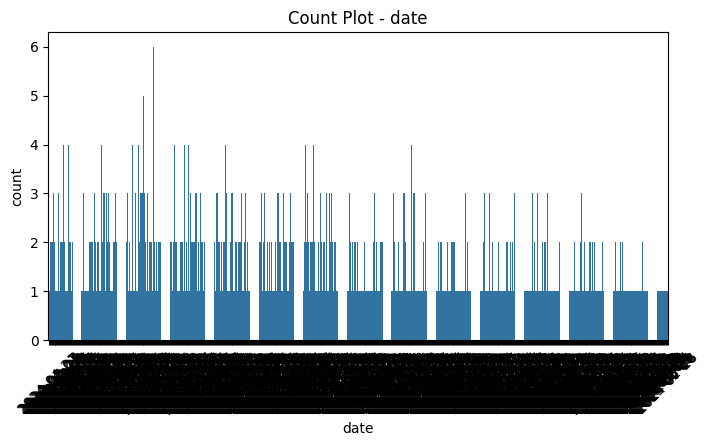

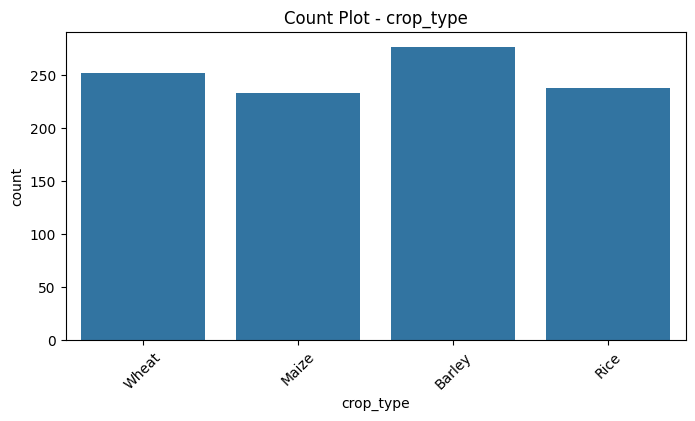

In [15]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot - {col}")
    plt.xticks(rotation=45)
    plt.show()


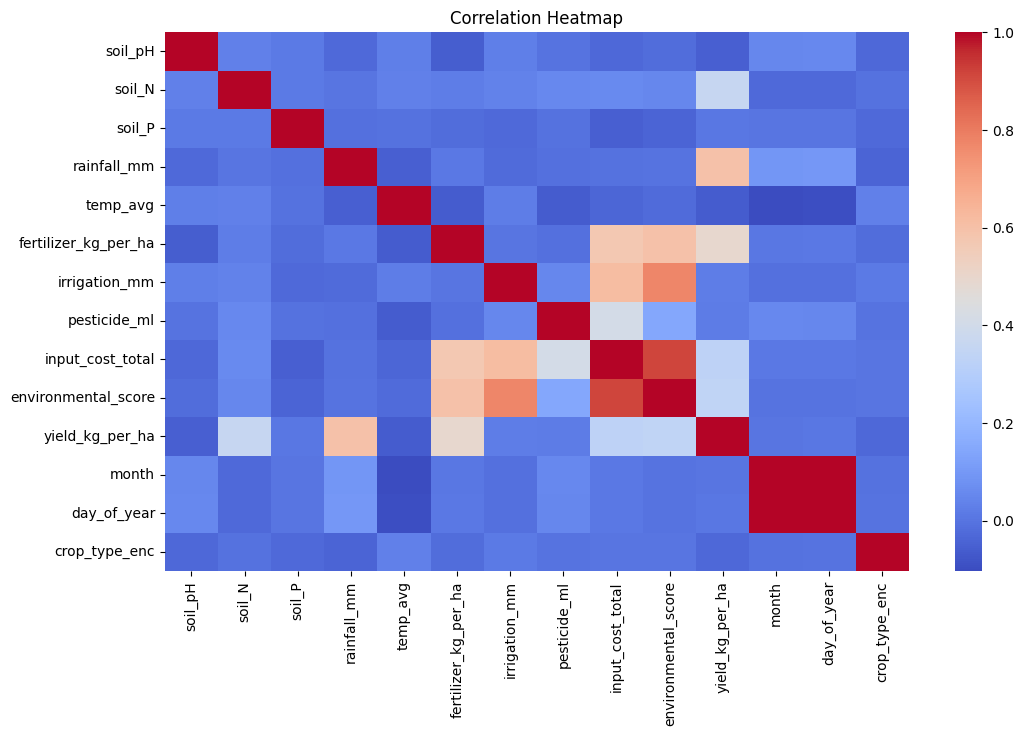

In [14]:
plt.figure(figsize=(12,7))
sns.heatmap(df_clean.select_dtypes(include='number').corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


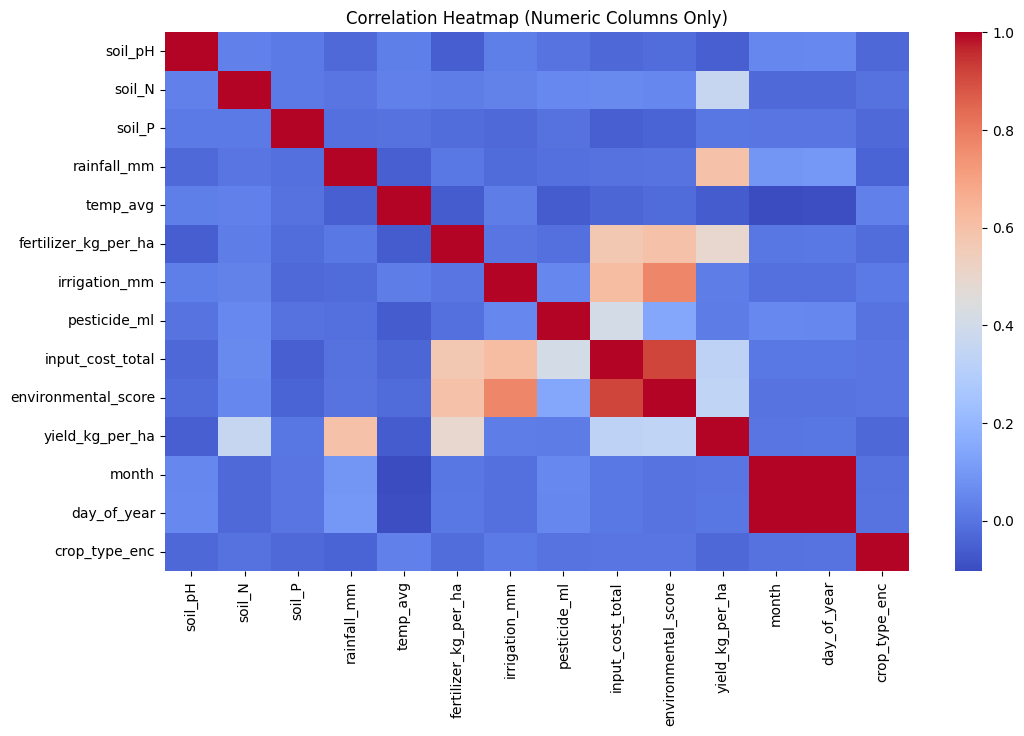

In [17]:
plt.figure(figsize=(12,7))
sns.heatmap(df_clean.select_dtypes(include=['float64', 'int64']).corr(), 
            cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()


# Yield Distribution

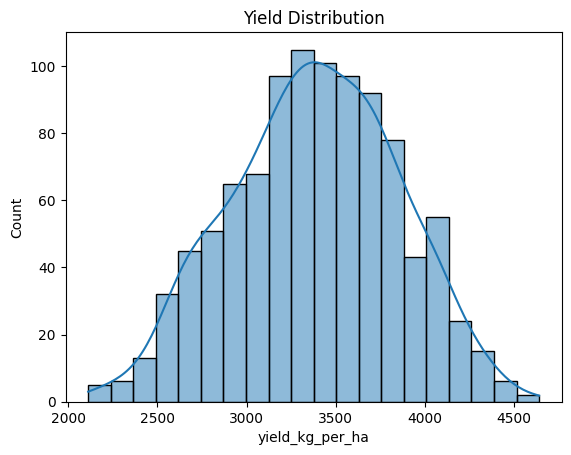

In [18]:
sns.histplot(df_clean["yield_kg_per_ha"], kde=True)
plt.title("Yield Distribution")
plt.show()


# Yield by Crop Type

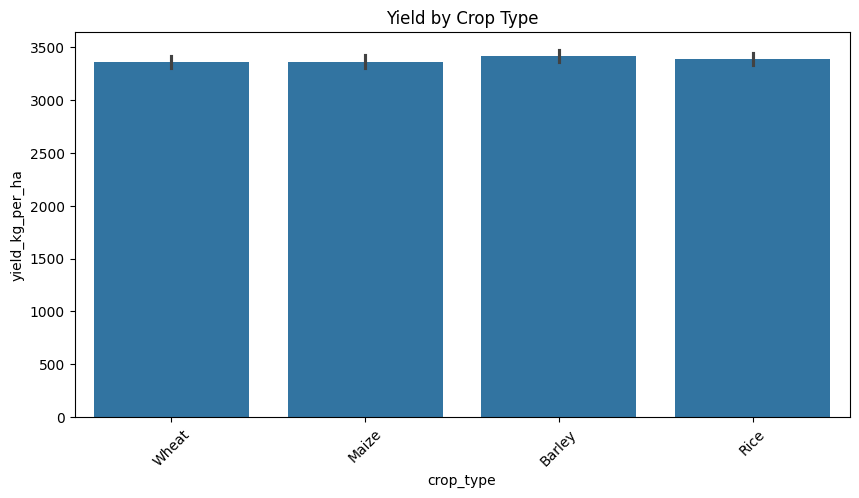

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_clean, x="crop_type", y="yield_kg_per_ha")
plt.xticks(rotation=45)
plt.title("Yield by Crop Type")
plt.show()


In [20]:
features = [
    'soil_pH','soil_N','soil_P','rainfall_mm','temp_avg',
    'fertilizer_kg_per_ha','irrigation_mm','pesticide_ml',
    'month','day_of_year','crop_type_enc'
]

X = df_clean[features]
y = df_clean['yield_kg_per_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=400, learning_rate=0.05)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)


# Metrics time

In [29]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_gbr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("Gradient Boosting R² Score:", r2)
print("Gradient Boosting RMSE:", rmse)


Gradient Boosting R² Score: 0.7220190019604334
Gradient Boosting RMSE: 241.39088245733555


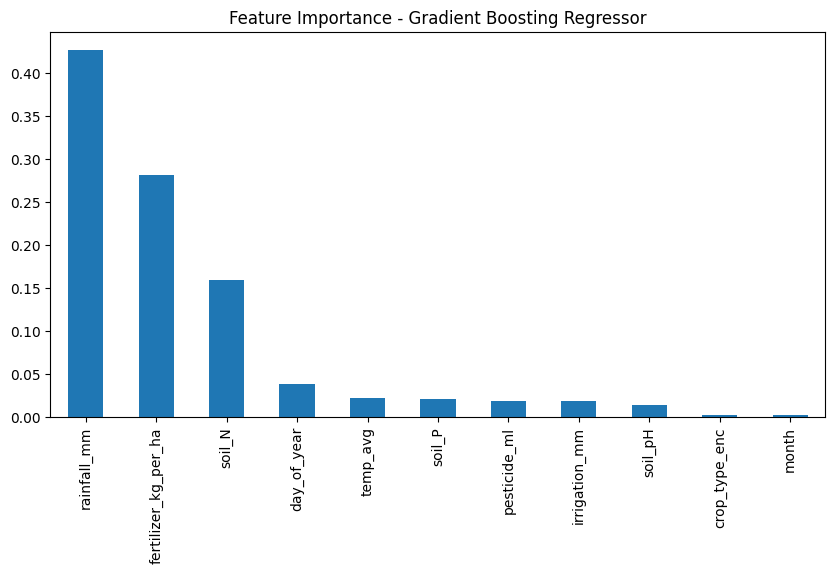

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(gbr.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Gradient Boosting Regressor")
plt.show()


In [31]:
!pip install shap


/opt/anaconda3/envs/akasha_de/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


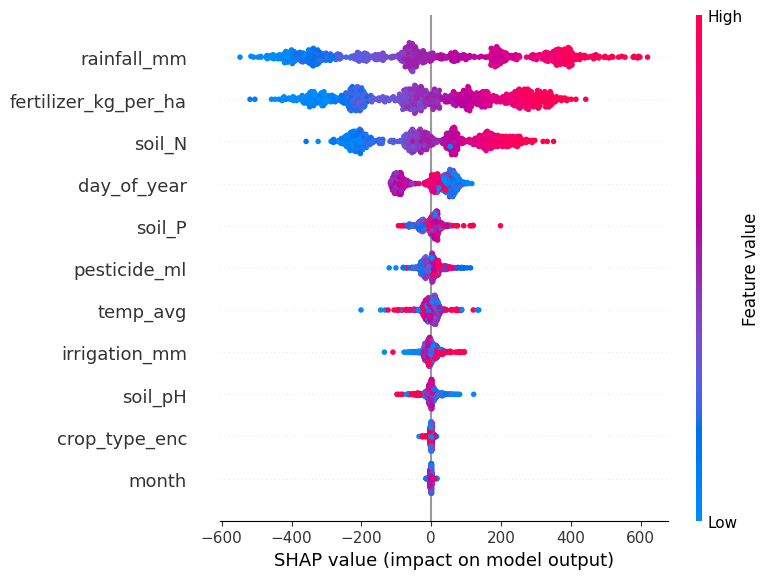

In [32]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(gbr)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)


# optimization grid search

In [33]:
fert_range = range(0, 301, 10)
irr_range = range(0, 401, 20)
pest_range = range(0, 201, 10)

best_yield = -1
best_plan = None

for fert in fert_range:
    for irr in irr_range:
        for pest in pest_range:

            # cost model (you can refine using your dataset logic)
            cost = fert * 12 + irr * 3 + pest * 8
            if cost > 12000:
                continue

            # environmental score (example formula)
            env = fert*2 + irr*1.5 + pest*3
            if env > 10000:
                continue
            
            # Create model input row
            sample = pd.DataFrame([[
                df_clean['soil_pH'].median(),
                df_clean['soil_N'].median(),
                df_clean['soil_P'].median(),
                df_clean['rainfall_mm'].median(),
                df_clean['temp_avg'].median(),
                fert,
                irr,
                pest,
                6,          # month
                150,        # day_of_year
                2           # crop_type_enc example
            ]], columns=X_train.columns)

            pred_y = gbr.predict(sample)[0]

            if pred_y > best_yield:
                best_yield = pred_y
                best_plan = (fert, irr, pest, cost, env)

best_plan, best_yield


((200, 20, 60, 2940, 610.0), np.float64(3802.2252022726457))